# Plotly

Key Features of Plotly
1. Interactivity:

- All plots are interactive by default, allowing zooming, panning, and hovering over data points to display tooltips.
2. High-Level and Low-Level APIs:

- `plotly.express`: A high-level interface for quick and easy plotting.
- `plotly.graph_objects`: A lower-level API for more customization and flexibility.

3. Integrations:

- Plotly integrates seamlessly with popular Python libraries like Pandas for data manipulation.
4. Compatibility:

- Plots render well in Jupyter Notebooks, web apps (via Dash), and static HTML reports.

Figure({
    'data': [{'hovertemplate': 'x=%{x}<br>y=%{y}<extra></extra>',
              'legendgroup': '',
              'line': {'color': '#636efa', 'dash': 'solid'},
              'marker': {'symbol': 'circle'},
              'mode': 'lines',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': array(['a', 'b', 'c'], dtype=object),
              'xaxis': 'x',
              'y': {'bdata': 'AQMC', 'dtype': 'i1'},
              'yaxis': 'y'}],
    'layout': {'legend': {'tracegroupgap': 0},
               'template': '...',
               'title': {'text': 'sample figure'},
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'x'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'y'}}}
})


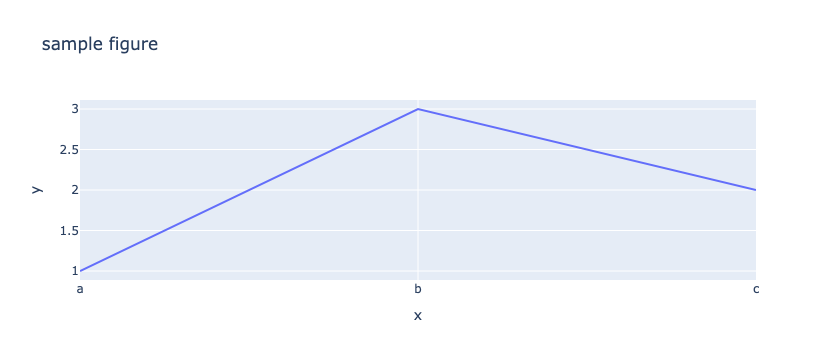

In [1]:
import plotly.express as px
import pandas as pd
import seaborn as sns

fig = px.line(x=["a","b","c"], y=[1,3,2], title="sample figure")
print(fig)
fig.show()

In [3]:
penguins = sns.load_dataset("penguins")

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


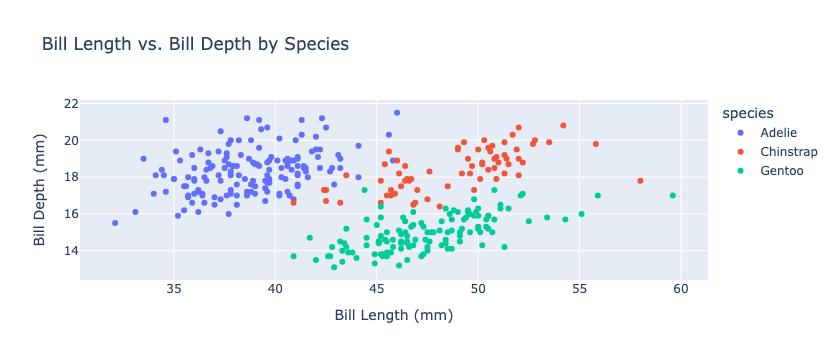

In [4]:
# Scatter plot for bill length vs. bill depth, colored by species
fig = px.scatter(
    penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    color="species",
    title="Bill Length vs. Bill Depth by Species",
    labels={"bill_length_mm": "Bill Length (mm)", "bill_depth_mm": "Bill Depth (mm)"}
)
fig.show()


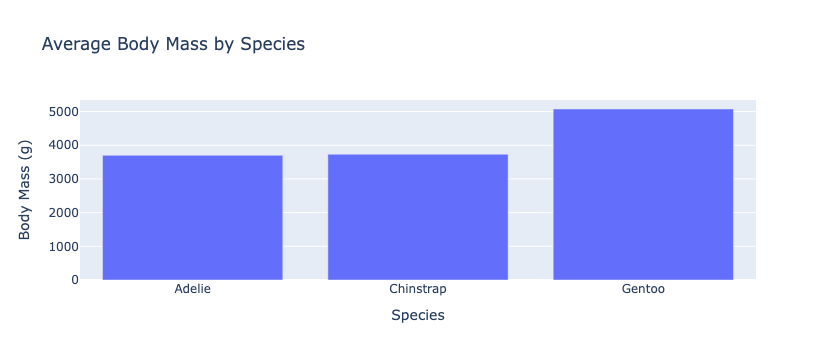

In [5]:
# Bar plot showing average body mass for each species
avg_mass = penguins.groupby("species")["body_mass_g"].mean().reset_index()

fig = px.bar(
    avg_mass,
    x="species",
    y="body_mass_g",
    title="Average Body Mass by Species",
    labels={"species": "Species", "body_mass_g": "Body Mass (g)"}
)
fig.show()


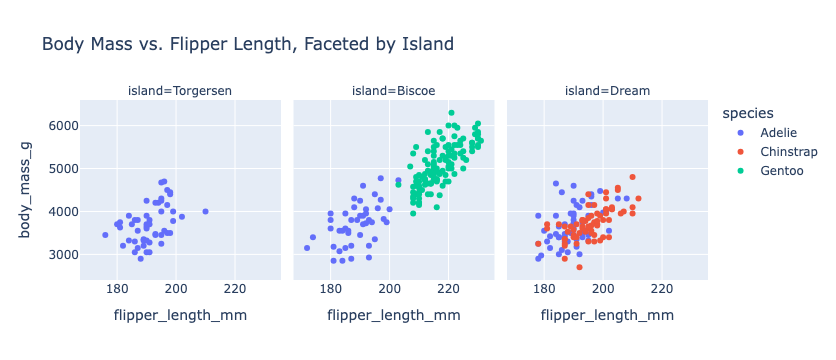

In [6]:
# Faceted scatter plot by island
fig = px.scatter(
    penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    color="species",
    facet_col="island",
    title="Body Mass vs. Flipper Length, Faceted by Island"
)
fig.show()


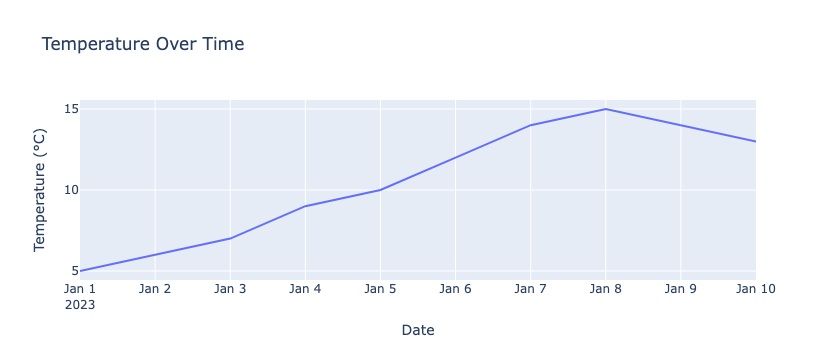

In [7]:
# Creating a toy dataset
time_data = pd.DataFrame({
    "time": pd.date_range(start="2023-01-01", periods=10),
    "temperature": [5, 6, 7, 9, 10, 12, 14, 15, 14, 13],
    "humidity": [70, 68, 65, 63, 60, 58, 55, 50, 52, 55]
})

# Line plot for temperature over time
fig = px.line(
    time_data,
    x="time",
    y="temperature",
    title="Temperature Over Time",
    labels={"time": "Date", "temperature": "Temperature (°C)"}
)
fig.show()


## Building Graphs with `plotly.graph_objects`
The `graph_objects` in Plotly lets you define each component of a visualization manually. Below are the steps for building a custom visualization:

- `go.Figure`: Creates a blank canvas for adding traces.
- `go.Scatter`: Represents a scatter plot; supports multiple modes (markers, lines, or both).
- `Customizations`: The update_layout method adjusts layout properties such as titles, axis labels, and styling.


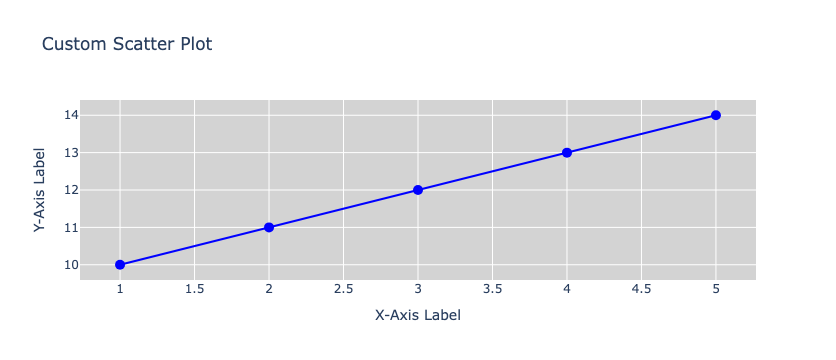

In [8]:

import plotly.graph_objects as go

# Creating a figure object
fig = go.Figure()

# Adding a scatter trace
fig.add_trace(
    go.Scatter(
        x=[1, 2, 3, 4, 5],   # X-axis values
        y=[10, 11, 12, 13, 14],  # Y-axis values
        mode='markers+lines',   # Marker and line mode
        name="Sample Data",     # Legend label
        marker=dict(color="blue", size=10),  # Customizing markers
    )
)

# Adding layout configurations
fig.update_layout(
    title="Custom Scatter Plot",
    xaxis_title="X-Axis Label",
    yaxis_title="Y-Axis Label",
    plot_bgcolor="lightgray"  # Background color
)

# Displaying the figure
fig.show()



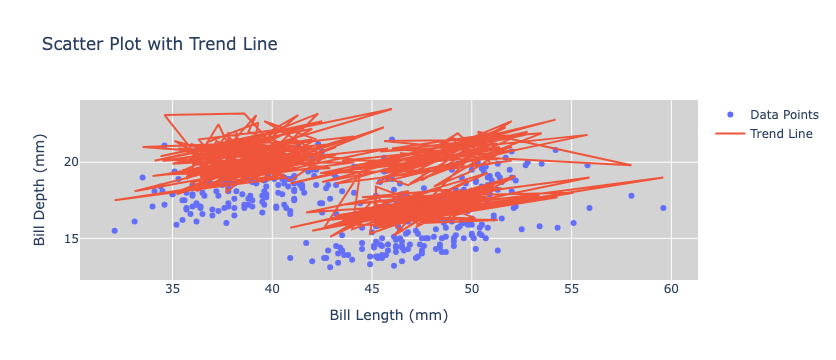

In [9]:
# Scatter and line combined
fig = go.Figure()

# Adding scatter plot
fig.add_trace(
    go.Scatter(
        x=penguins["bill_length_mm"],
        y=penguins["bill_depth_mm"],
        mode="markers",
        name="Data Points"
    )
)

# Adding a trend line
fig.add_trace(
    go.Scatter(
        x=penguins["bill_length_mm"],
        y=penguins["bill_depth_mm"] + 2,  # Adding a simple trend for demonstration
        mode="lines",
        name="Trend Line"
    )
)

# Layout customization
fig.update_layout(
    title="Scatter Plot with Trend Line",
    xaxis_title="Bill Length (mm)",
    yaxis_title="Bill Depth (mm)",
    plot_bgcolor="lightgrey"
)

fig.show()


## Animation

Plotly also supports animations, allowing visualizations to change dynamically over a specific variable (e.g., time).

- Specify `animation_frame`: The variable to animate over (e.g., year).
- Define `animation_group`: Grouping variable (e.g., country) to keep data points consistent across frames.

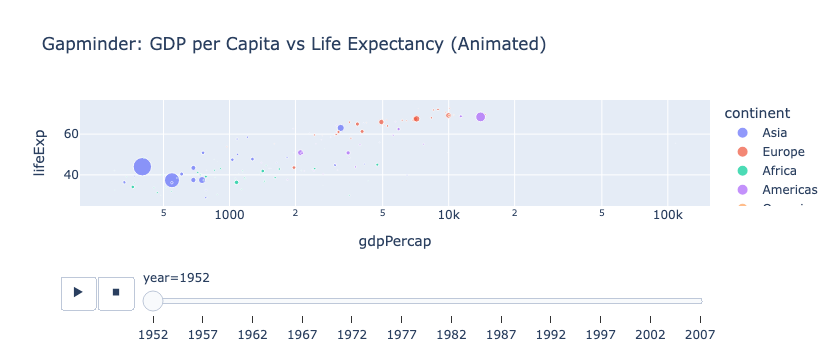

In [10]:
# Animation using gapminder dataset
gapminder = px.data.gapminder()

fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True,
    animation_frame="year",
    animation_group="country",
    title="Gapminder: GDP per Capita vs Life Expectancy (Animated)"
)
fig.show()
